In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# import excel data
frames = []
for i in range(100):
    df_sheet = pd.read_excel(f"problematicData/diag_data{i}.xlsx")
    frames.append(df_sheet)

df = pd.concat(frames)
df

,Unnamed: 0,seed,col,n_nodes,n_nodes_used,is_regressor,unused_nodes,percentage,accuracy,n_nan_in_threshold
0,0,0,0,1,1,False,0,0.000000,0.120000,0
1,1,0,1,23,23,True,0,0.000000,0.293356,0
2,2,0,2,27,27,False,0,0.000000,0.320000,0
3,3,0,3,29,29,True,0,0.000000,0.588977,0
4,4,0,4,31,31,False,0,0.000000,0.460000,0
...,...,...,...,...,...,...,...,...,...,...
96,96,99,96,33,21,False,12,36.363636,0.200000,4
97,97,99,97,19,19,True,0,0.000000,0.905649,0
98,98,99,98,25,15,False,10,40.000000,0.380000,4
99,99,99,99,31,31,True,0,0.000000,0.882794,0


([<matplotlib.patches.Wedge at 0x28cd8c420d0>,
 [Text(-0.01710713123828362, 1.0998669674377881, 'total regressors'),
  Text(0.017107096277351748, -1.0998669679815636, 'total classifiers')],
 [Text(-0.009331162493609246, 0.599927436784248, '50.5%'),
  Text(0.009331143424010044, -0.5999274370808527, '49.5%')])

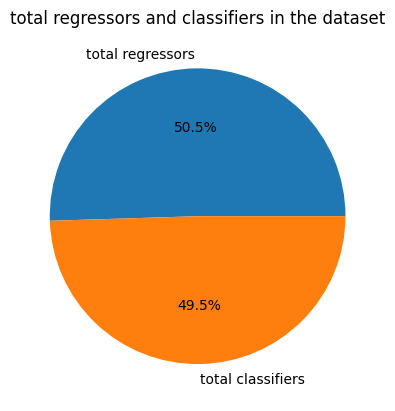

In [29]:
fig, ax = plt.subplots()
ax.set_title("total regressors and classifiers in the dataset")
n_reg = df["is_regressor"].sum()
n_clf = df.shape[0] -n_reg
sizes = [n_reg,n_clf]
labels = "total regressors","total classifiers"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')


In [30]:
m_clf = df["is_regressor"]==False
m_reg = df["is_regressor"]==True
m_no_target = df["col"] != "target"
m_has_difference = df["unused_nodes"] != 0

([<matplotlib.patches.Wedge at 0x28cd8a35810>,
 [Text(1.0994879201747776, 0.03356059280975261, 'total regressors'),
  Text(-1.0994879134275952, -0.033560813855348814, 'total classifiers')],
 [Text(0.5997206837316968, 0.018305777896228698, '1.0%'),
  Text(-0.5997206800514154, -0.018305898466553897, '99.0%')])

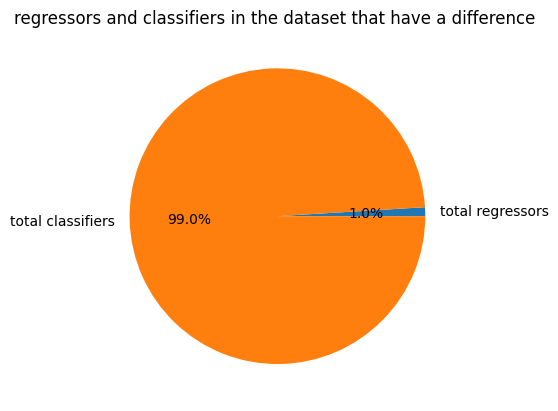

In [31]:
fig, ax = plt.subplots()
ax.set_title("regressors and classifiers in the dataset that have a difference ")
n_reg = df[m_has_difference]["is_regressor"].sum()
n_clf = df[m_has_difference].shape[0] -n_reg
sizes = [n_reg,n_clf]
labels = "total regressors","total classifiers"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

In [32]:
df["has_difference"] = m_has_difference
df[["is_regressor","has_difference"]].value_counts(normalize=True)

is_regressor  has_difference
True          False             0.502772
False         False             0.272970
              True              0.222079
True          True              0.002178
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x28cd8a656d0>,
 [Text(0.838110874721048, 0.7124395845784539, 'not all nodes reached'),
  Text(-0.8381106425787209, -0.7124398576696026, 'all nodes reached')],
 [Text(0.45715138621148066, 0.38860340977006574, '22.4%'),
  Text(-0.4571512595883932, -0.3886035587288741, '77.6%')])

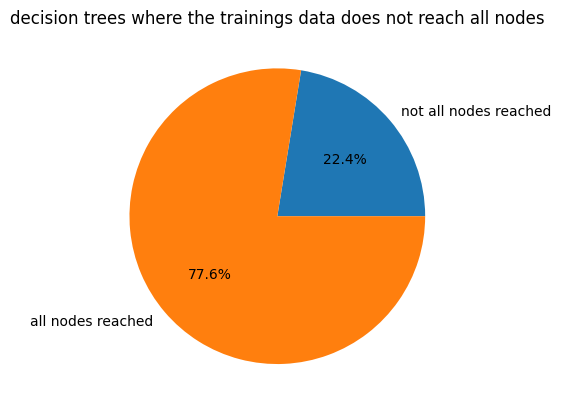

In [33]:
fig, ax = plt.subplots()
ax.set_title("decision trees where the trainings data does not reach all nodes")
n_has_diff = df["has_difference"].sum()
n_no_diff = df.shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

In [34]:
df[m_clf][["is_regressor","has_difference"]].value_counts(normalize=True)

is_regressor  has_difference
False         False             0.5514
              True              0.4486
Name: proportion, dtype: float64

In [35]:
df[m_reg][["is_regressor","has_difference"]].value_counts(normalize=False)

is_regressor  has_difference
True          False             5078
              True                22
Name: count, dtype: int64

In [36]:
df[m_reg][["is_regressor","has_difference"]].value_counts(normalize=True)*100

is_regressor  has_difference
True          False             99.568627
              True               0.431373
Name: proportion, dtype: float64

<Axes: xlabel='col', ylabel='unused_nodes'>

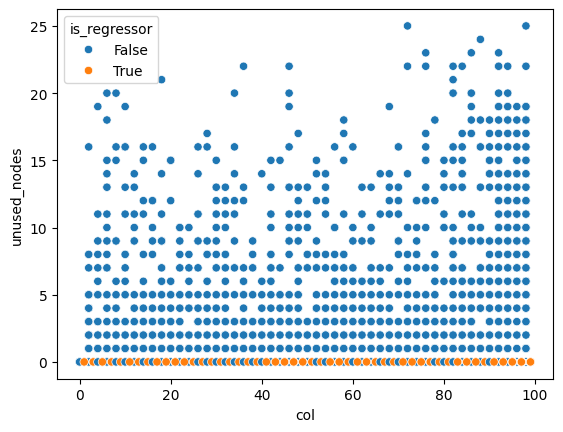

In [37]:
sns.scatterplot(data=df[m_no_target],x="col",y="unused_nodes",hue="is_regressor")

([<matplotlib.patches.Wedge at 0x28cd8ea8050>,
 [Text(0.8475645368507168, 0.7011664252322912, 'not all nodes reached'),
  Text(-0.8475644755527953, -0.7011664993287365, 'all nodes reached')],
 [Text(0.4623079291913, 0.3824544137630679, '22.0%'),
  Text(-0.4623078957560701, -0.38245445417931084, '78.0%')])

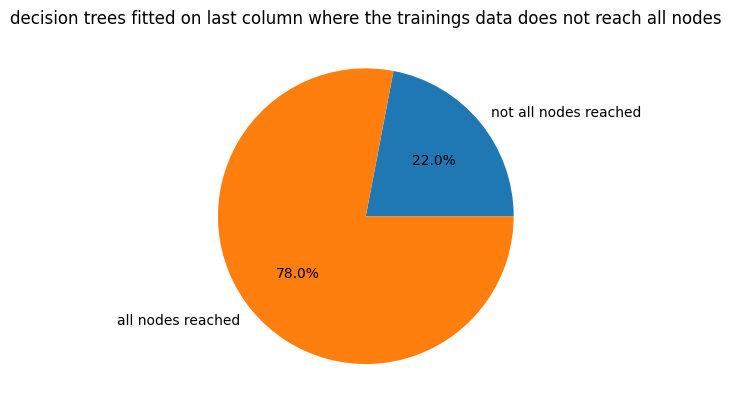

In [38]:
#sns.scatterplot(data=df[m_no_target & m_reg],x="col",y="unused_nodes")

fig, ax = plt.subplots()
ax.set_title("decision trees fitted on last column where the trainings data does not reach all nodes")
n_has_diff = df[~m_no_target]["has_difference"].sum()
n_no_diff = df[~m_no_target].shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x28cd8eabb10>,
 [Text(0.1768547387650355, 1.0856898274260247, 'not all nodes reached'),
  Text(-0.17685438500237718, -1.0856898850525556, 'all nodes reached')],
 [Text(0.0964662211445648, 0.5921944513232862, '44.9%'),
  Text(-0.09646602818311481, -0.5921944827559393, '55.1%')])

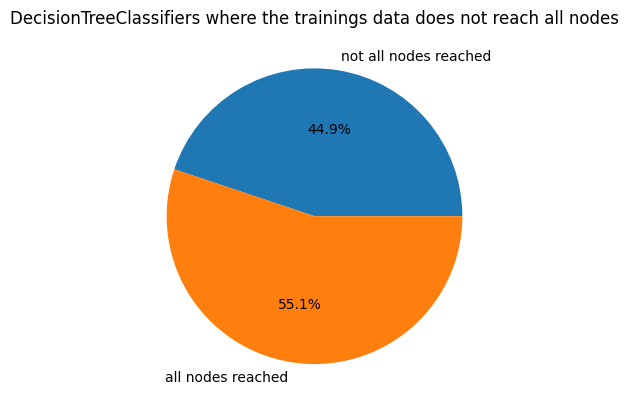

In [39]:
fig, ax = plt.subplots()
ax.set_title("DecisionTreeClassifiers where the trainings data does not reach all nodes")
n_has_diff = df[~m_reg]["has_difference"].sum()
n_no_diff = df[~m_reg].shape[0] - n_has_diff
sizes = [n_has_diff,n_no_diff]
labels = "not all nodes reached","all nodes reached"
ax.pie(sizes,labels=labels, autopct='%1.1f%%')

<Axes: xlabel='percentage', ylabel='accuracy'>

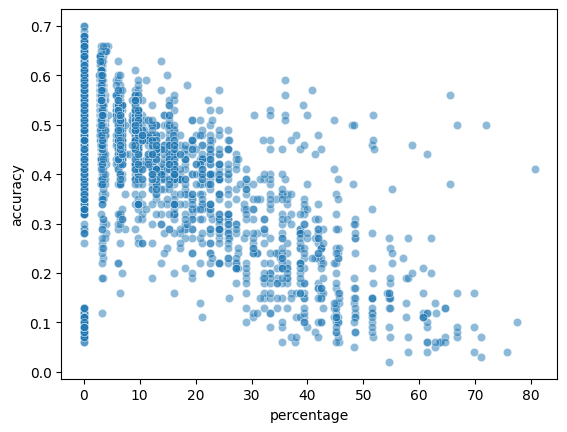

In [40]:
sns.scatterplot(data=df[~m_reg],x="percentage",y="accuracy",alpha=0.5)

<Axes: xlabel='unused_nodes', ylabel='accuracy'>

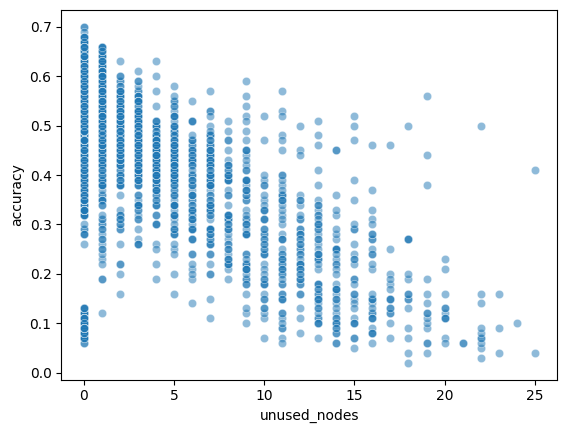

In [41]:
sns.scatterplot(data=df[~m_reg],x="unused_nodes",y="accuracy",alpha=0.5)

In [42]:
#sns.scatterplot(data=df[m_reg],x="percentage",y="accuracy",alpha=0.5)

<Axes: xlabel='has_difference', ylabel='accuracy'>

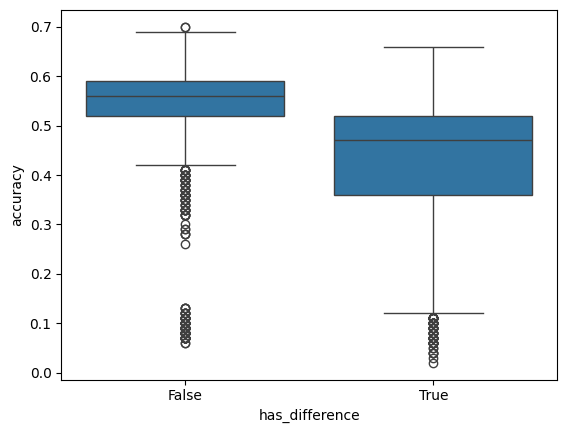

In [43]:
sns.boxplot(data =df[~m_reg],x="has_difference",y="accuracy")

<Axes: xlabel='accuracy', ylabel='Count'>

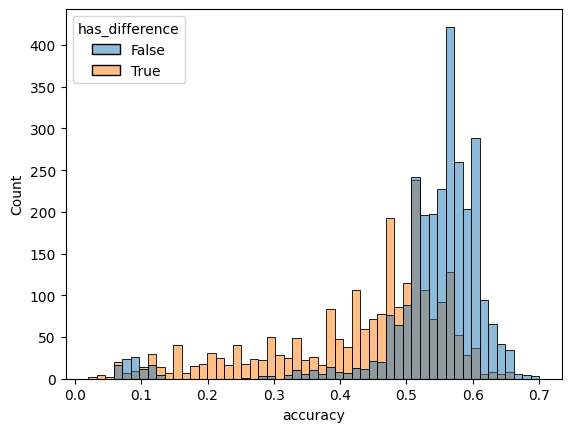

In [44]:
sns.histplot(data =df[~m_reg],x="accuracy",hue="has_difference")

<Axes: xlabel='accuracy', ylabel='Count'>

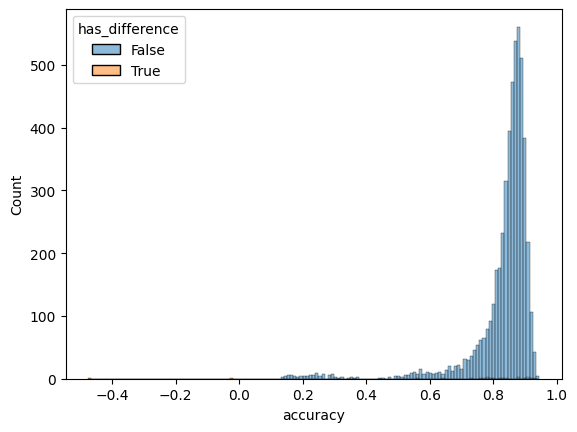

In [45]:
sns.histplot(data =df[m_reg],x="accuracy",hue="has_difference")

<Axes: xlabel='unused_nodes', ylabel='n_nan_in_threshold'>

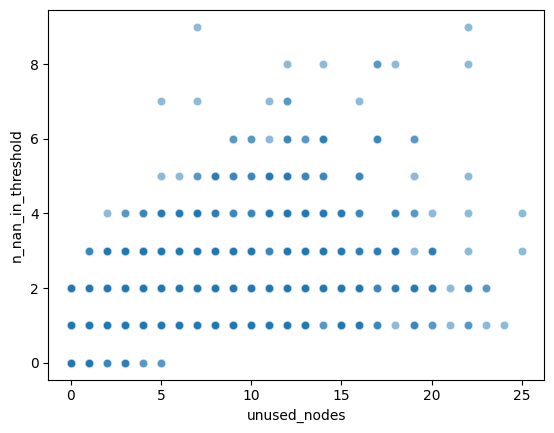

In [46]:
sns.scatterplot(data=df[~m_reg],x="unused_nodes",y="n_nan_in_threshold",alpha=0.5)

In [47]:
df["no_nan_in_threshold"] = df["n_nan_in_threshold"] == 0

In [48]:
df[["no_nan_in_threshold","has_difference"]].value_counts(normalize=False)

no_nan_in_threshold  has_difference
True                 False             7654
False                True              2239
                     False              181
True                 True                26
Name: count, dtype: int64

In [49]:
df[["no_nan_in_threshold","has_difference"]].value_counts(normalize=True)

no_nan_in_threshold  has_difference
True                 False             0.757822
False                True              0.221683
                     False             0.017921
True                 True              0.002574
Name: proportion, dtype: float64

In [50]:
m_other_situation = df["no_nan_in_threshold"] & df["has_difference"]
df[m_other_situation]

,Unnamed: 0,seed,col,n_nodes,n_nodes_used,is_regressor,unused_nodes,percentage,accuracy,n_nan_in_threshold,has_difference,no_nan_in_threshold
92,92,3,92,31,30,False,1,3.225806,0.53,0,True,True
78,78,16,78,33,32,False,1,3.030303,0.54,0,True,True
74,74,20,74,29,28,False,1,3.448276,0.19,0,True,True
12,12,21,12,29,28,False,1,3.448276,0.30,0,True,True
78,78,21,78,35,33,False,2,5.714286,0.42,0,True,True
98,98,30,98,27,26,False,1,3.703704,0.56,0,True,True
76,76,32,76,31,30,False,1,3.225806,0.22,0,True,True
86,86,33,86,29,26,False,3,10.344828,0.48,0,True,True
42,42,57,42,31,30,False,1,3.225806,0.12,0,True,True
46,46,57,46,29,26,False,3,10.344828,0.26,0,True,True


In [51]:
props = df[["no_nan_in_threshold","has_difference"]].value_counts(normalize=True)
p_has_nan_in_threshold = props[False][True] +props[False][False]
p_has_difference_and_nan_in_threshold = props[False][True]
p_has_difference_given_nan_in_threshold = p_has_difference_and_nan_in_threshold / p_has_nan_in_threshold
print(f"the probapilty of trainingsdata not reaching all nodes given that the thresholds contain nans is {p_has_difference_given_nan_in_threshold}")

the probapilty of trainingsdata not reaching all nodes given that the thresholds contain nans is 0.925206611570248


In [52]:
p_has_no_nan_in_threshold = props[True][True] +props[True][False]
p_has_difference_and_no_nan_in_threshold = props[True][True]
p_has_difference_given_no_nan_in_threshold = p_has_difference_and_no_nan_in_threshold / p_has_no_nan_in_threshold
print(f"the probapilty of trainingsdata not reaching all nodes given that the thresholds contain NO nans is {p_has_difference_given_no_nan_in_threshold}")

the probapilty of trainingsdata not reaching all nodes given that the thresholds contain NO nans is 0.0033854166666666668


In [53]:
p_has_difference = props[True][True] +props[False][True]
p_has_difference_and_nan_in_threshold = props[False][True]
p_nan_in_threshold_given_has_difference= p_has_difference_and_nan_in_threshold / p_has_difference
print(f"the probability of having a nan in the threshold given that the trainingsdata does not reach all nodes is {p_nan_in_threshold_given_has_difference}")

the probability of having a nan in the threshold given that the trainingsdata does not reach all nodes is 0.9885209713024282
